<a href="https://colab.research.google.com/github/devunisathish/NASSCOM-MODULE-1/blob/main/PRO/MADAMS_CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Human Activity Pattern Discovery Using Smartphone Sensor Data: A Comparative Clustering Analysis

In [ ]:
from google.colab import files
files.upload()

In [3]:
import pandas as pd

train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

train.head()

Train Shape: (7352, 563)
Test Shape : (2947, 563)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [4]:
print(train.columns.tolist())

['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X', 'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z', 'tBodyAcc-min()-X', 'tBodyAcc-min()-Y', 'tBodyAcc-min()-Z', 'tBodyAcc-sma()', 'tBodyAcc-energy()-X', 'tBodyAcc-energy()-Y', 'tBodyAcc-energy()-Z', 'tBodyAcc-iqr()-X', 'tBodyAcc-iqr()-Y', 'tBodyAcc-iqr()-Z', 'tBodyAcc-entropy()-X', 'tBodyAcc-entropy()-Y', 'tBodyAcc-entropy()-Z', 'tBodyAcc-arCoeff()-X,1', 'tBodyAcc-arCoeff()-X,2', 'tBodyAcc-arCoeff()-X,3', 'tBodyAcc-arCoeff()-X,4', 'tBodyAcc-arCoeff()-Y,1', 'tBodyAcc-arCoeff()-Y,2', 'tBodyAcc-arCoeff()-Y,3', 'tBodyAcc-arCoeff()-Y,4', 'tBodyAcc-arCoeff()-Z,1', 'tBodyAcc-arCoeff()-Z,2', 'tBodyAcc-arCoeff()-Z,3', 'tBodyAcc-arCoeff()-Z,4', 'tBodyAcc-correlation()-X,Y', 'tBodyAcc-correlation()-X,Z', 'tBodyAcc-correlation()-Y,Z', 'tGravityAcc-mean()-X', 'tGravityAcc-mean()-Y', 'tGravityAcc-mean()-Z', 'tG

In [5]:
df = pd.concat(
    [train, test],
    axis=0,
    ignore_index=True
)

print(df.shape)

(10299, 563)


In [6]:
for col in df.columns:
    print(col)

tBodyAcc-mean()-X
tBodyAcc-mean()-Y
tBodyAcc-mean()-Z
tBodyAcc-std()-X
tBodyAcc-std()-Y
tBodyAcc-std()-Z
tBodyAcc-mad()-X
tBodyAcc-mad()-Y
tBodyAcc-mad()-Z
tBodyAcc-max()-X
tBodyAcc-max()-Y
tBodyAcc-max()-Z
tBodyAcc-min()-X
tBodyAcc-min()-Y
tBodyAcc-min()-Z
tBodyAcc-sma()
tBodyAcc-energy()-X
tBodyAcc-energy()-Y
tBodyAcc-energy()-Z
tBodyAcc-iqr()-X
tBodyAcc-iqr()-Y
tBodyAcc-iqr()-Z
tBodyAcc-entropy()-X
tBodyAcc-entropy()-Y
tBodyAcc-entropy()-Z
tBodyAcc-arCoeff()-X,1
tBodyAcc-arCoeff()-X,2
tBodyAcc-arCoeff()-X,3
tBodyAcc-arCoeff()-X,4
tBodyAcc-arCoeff()-Y,1
tBodyAcc-arCoeff()-Y,2
tBodyAcc-arCoeff()-Y,3
tBodyAcc-arCoeff()-Y,4
tBodyAcc-arCoeff()-Z,1
tBodyAcc-arCoeff()-Z,2
tBodyAcc-arCoeff()-Z,3
tBodyAcc-arCoeff()-Z,4
tBodyAcc-correlation()-X,Y
tBodyAcc-correlation()-X,Z
tBodyAcc-correlation()-Y,Z
tGravityAcc-mean()-X
tGravityAcc-mean()-Y
tGravityAcc-mean()-Z
tGravityAcc-std()-X
tGravityAcc-std()-Y
tGravityAcc-std()-Z
tGravityAcc-mad()-X
tGravityAcc-mad()-Y
tGravityAcc-mad()-Z
tGravityAcc-m

In [7]:
y = df['Activity']

X = df.drop(
    columns=['Activity']
)

print(X.shape)
print(y.shape)

(10299, 562)
(10299,)


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(le.classes_)

['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(10299, 562)


In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("Original Features:", X.shape[1])
print("PCA Features:", X_pca.shape[1])

Original Features: 562
PCA Features: 105


In [11]:
print(train.columns[:20])
print(train.shape)
print(test.shape)

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X', 'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z',
       'tBodyAcc-min()-X', 'tBodyAcc-min()-Y', 'tBodyAcc-min()-Z',
       'tBodyAcc-sma()', 'tBodyAcc-energy()-X', 'tBodyAcc-energy()-Y',
       'tBodyAcc-energy()-Z', 'tBodyAcc-iqr()-X'],
      dtype='object')
(7352, 563)
(2947, 563)


In [12]:
print(train.columns[-10:])

Index(['fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity'],
      dtype='object')


In [13]:
print(train[['subject','Activity']].head())

   subject  Activity
0        1  STANDING
1        1  STANDING
2        1  STANDING
3        1  STANDING
4        1  STANDING


In [14]:
import pandas as pd

df = pd.concat(
    [train, test],
    ignore_index=True
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (10299, 563)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [15]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10299 entries, 0 to 10298
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 44.2+ MB
None

Missing Values:
0

Duplicate Rows:
0


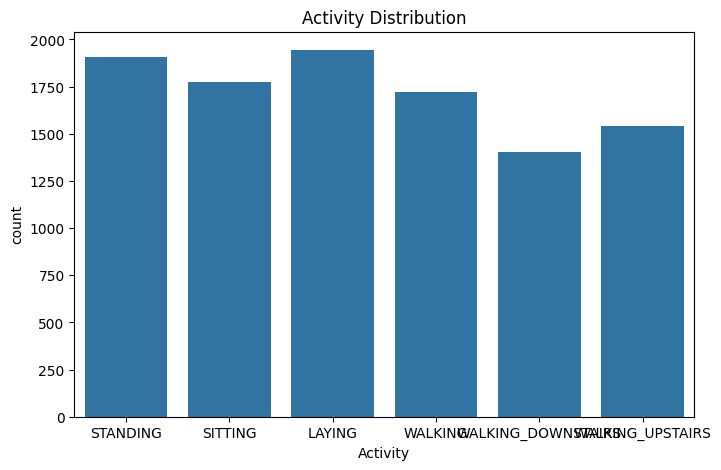

Activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x='Activity',
    data=df
)

plt.title("Activity Distribution")

plt.show()

print(df['Activity'].value_counts())

In [17]:
X = df.drop(
    columns=[
        'Activity',
        'subject'
    ]
)

y = df['Activity']

print(X.shape)

(10299, 561)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(10299, 561)


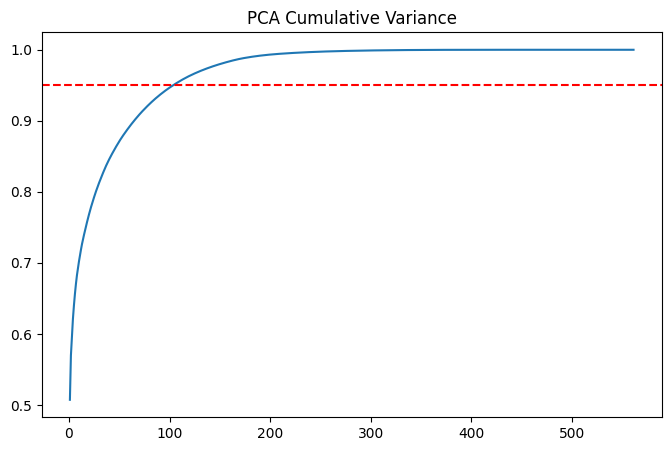

In [19]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()

pca.fit(X_scaled)

cum_var = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(cum_var)+1),
    cum_var
)

plt.axhline(
    y=0.95,
    color='red',
    linestyle='--'
)

plt.title(
    "PCA Cumulative Variance"
)

plt.show()

In [20]:
pca = PCA(
    n_components=0.95
)

X_pca = pca.fit_transform(
    X_scaled
)

print(
    "Original:",
    X_scaled.shape
)

print(
    "PCA:",
    X_pca.shape
)

Original: (10299, 561)
PCA: (10299, 104)


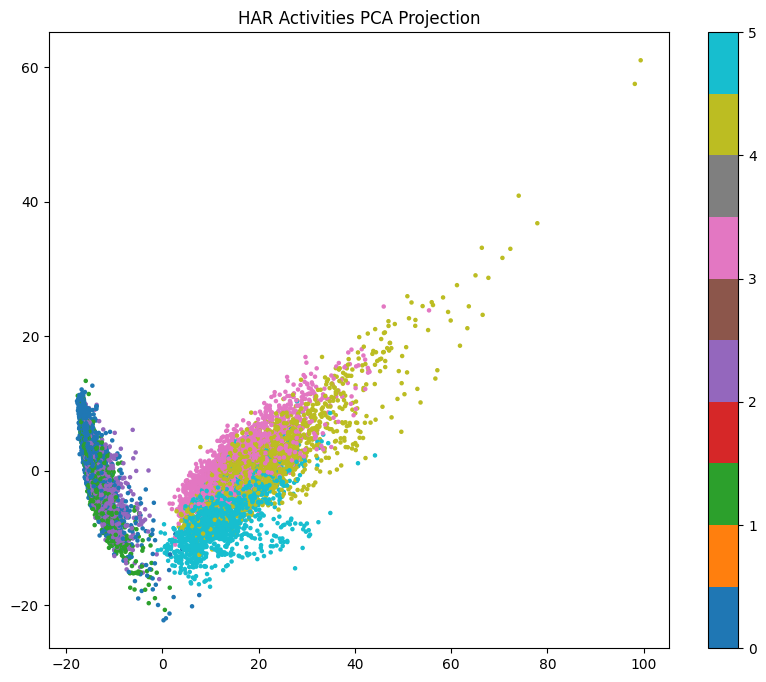

In [22]:
pca2 = PCA(
    n_components=2
)

X_vis = pca2.fit_transform(
    X_scaled
)

plt.figure(figsize=(10,8))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=y_encoded,
    cmap='tab10',
    s=5
)

plt.colorbar()

plt.title(
    "HAR Activities PCA Projection"
)

plt.show()

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X,y)

importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(
    importance.head(20)
)

                             Feature  Importance
40              tGravityAcc-mean()-X    0.037120
49               tGravityAcc-max()-X    0.032881
558             angle(X,gravityMean)    0.031846
56            tGravityAcc-energy()-X    0.027499
41              tGravityAcc-mean()-Y    0.024777
52               tGravityAcc-min()-X    0.020739
50               tGravityAcc-max()-Y    0.020083
559             angle(Y,gravityMean)    0.019457
53               tGravityAcc-min()-Y    0.018596
57            tGravityAcc-energy()-Y    0.012215
83              tBodyAccJerk-std()-X    0.012148
560             angle(Z,gravityMean)    0.011463
389  fBodyAccJerk-bandsEnergy()-1,16    0.011286
3                   tBodyAcc-std()-X    0.011199
201                tBodyAccMag-std()    0.010903
74         tGravityAcc-arCoeff()-Z,2    0.010394
393  fBodyAccJerk-bandsEnergy()-1,24    0.010292
181            tBodyGyroJerk-iqr()-Z    0.010216
69         tGravityAcc-arCoeff()-Y,1    0.009196
508             fBod

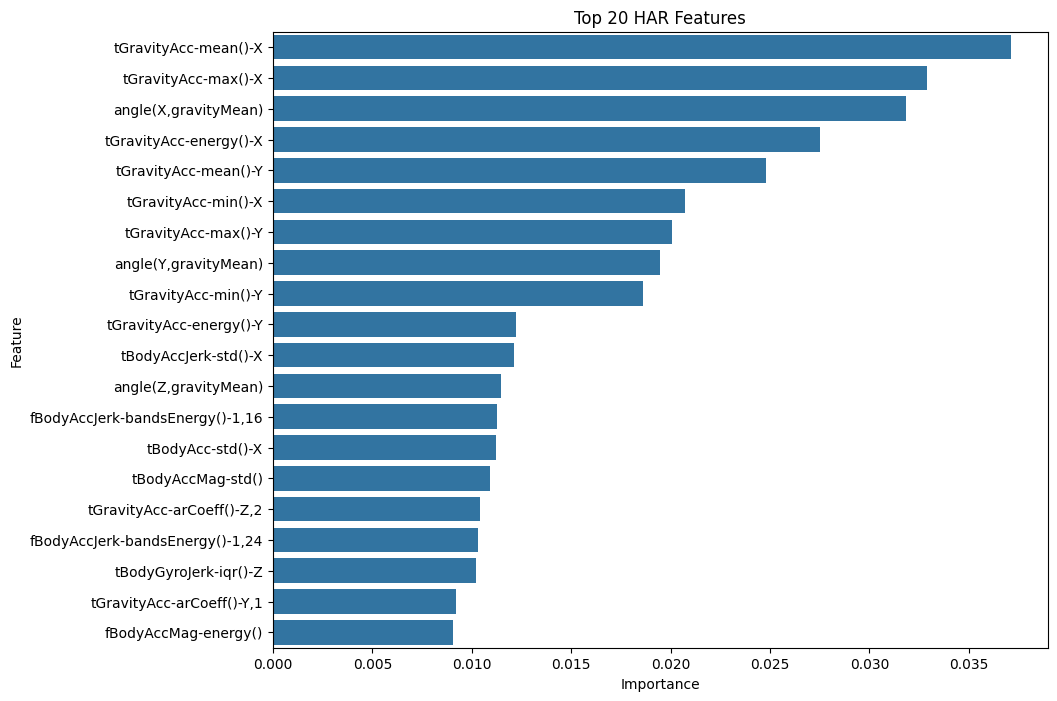

In [24]:
plt.figure(figsize=(10,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(20)
)

plt.title(
    "Top 20 HAR Features"
)

plt.show()

In [25]:
top_features = (
    importance
    .head(50)
    ['Feature']
    .tolist()
)

X_selected = X[top_features]

print(
    X_selected.shape
)

(10299, 50)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_selected
)

print(X_scaled.shape)

(10299, 50)


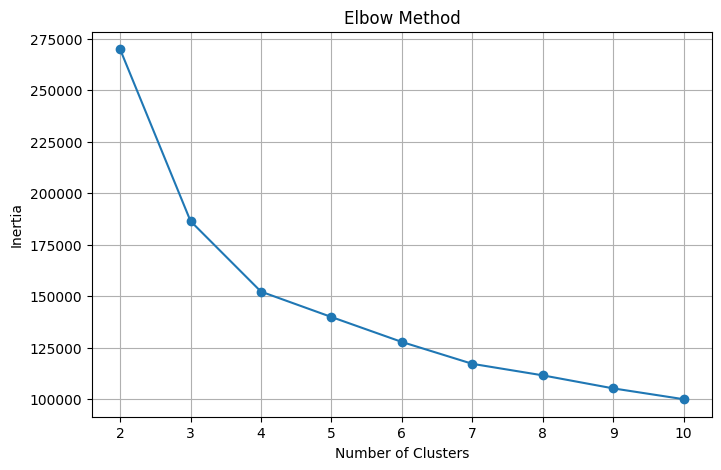

In [27]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)

    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

k=2  Silhouette=0.4313
k=3  Silhouette=0.4459
k=4  Silhouette=0.3815
k=5  Silhouette=0.3572
k=6  Silhouette=0.2773
k=7  Silhouette=0.2381
k=8  Silhouette=0.2305
k=9  Silhouette=0.2303
k=10  Silhouette=0.2371


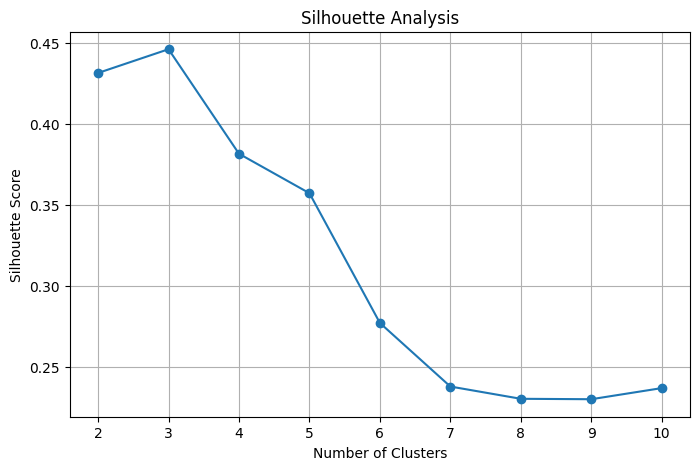

In [28]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2,11):

    labels = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    ).fit_predict(X_scaled)

    sil = silhouette_score(
        X_scaled,
        labels
    )

    sil_scores.append(sil)

    print(
        f"k={k}  Silhouette={sil:.4f}"
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    sil_scores,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

In [29]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

k_labels = kmeans.fit_predict(X_scaled)

print("KMeans completed")

KMeans completed


HAR dataset contains around 10,299 records. Some clustering algorithms (especially Hierarchical Clustering) require a lot of memory and processing time when run on the entire dataset.

Therefore:

Randomly select 3000 samples.
Use the smaller dataset (X_sub) for computationally expensive algorithms.
Reduce RAM usage and execution time.
Prevent Google Colab from crashing or disconnecting.

In [30]:
import numpy as np

idx = np.random.choice(
    len(X_scaled),
    3000,
    replace=False
)

X_sub = X_scaled[idx]
y_sub = y.iloc[idx]

print(X_sub.shape)

(3000, 50)


In [31]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=3
)

h_labels = hc.fit_predict(X_sub)

print("Hierarchical completed")

Hierarchical completed


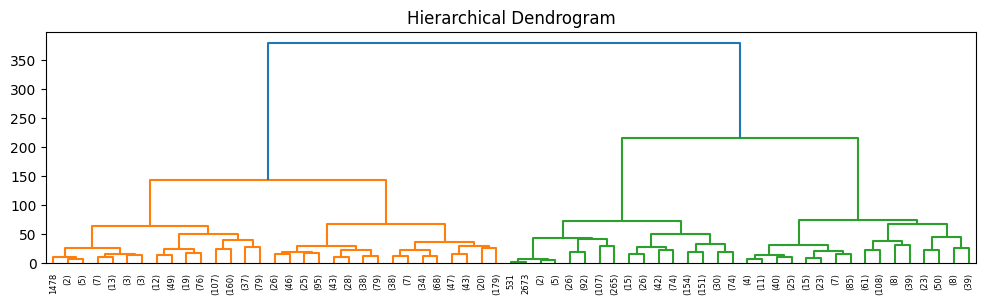

In [32]:
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

Z = linkage(
    X_sub,
    method='ward'
)

plt.figure(figsize=(12,3))

dendrogram(
    Z,
    truncate_mode='level',
    p=5
)

plt.title("Hierarchical Dendrogram")
plt.show()

In [33]:
from sklearn.cluster import DBSCAN

db = DBSCAN(
    eps=3,
    min_samples=10
)

db_labels = db.fit_predict(X_scaled)

print(
    "Clusters Found:",
    len(set(db_labels)) -
    (1 if -1 in db_labels else 0)
)

print(
    "Noise Points:",
    sum(db_labels==-1)
)

Clusters Found: 3
Noise Points: 123


In [34]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

g_labels = gmm.fit_predict(X_scaled)

print("GMM completed")

GMM completed


In [35]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

results = []

# KMeans
results.append([
    "KMeans",
    silhouette_score(X_scaled, k_labels),
    davies_bouldin_score(X_scaled, k_labels),
    calinski_harabasz_score(X_scaled, k_labels)
])

# Hierarchical
results.append([
    "Hierarchical",
    silhouette_score(X_sub, h_labels),
    davies_bouldin_score(X_sub, h_labels),
    calinski_harabasz_score(X_sub, h_labels)
])

# GMM
results.append([
    "GMM",
    silhouette_score(X_scaled, g_labels),
    davies_bouldin_score(X_scaled, g_labels),
    calinski_harabasz_score(X_scaled, g_labels)
])

comparison = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Silhouette",
        "DBI",
        "CHI"
    ]
)

comparison = comparison.round(4)

print(comparison)

      Algorithm  Silhouette     DBI        CHI
0        KMeans      0.4459  0.8894  9067.6979
1  Hierarchical      0.4456  0.8867  2619.7399
2           GMM      0.2102  1.6432  4901.4521


In [36]:
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score
)

external = []

external.append([
    "KMeans",
    adjusted_rand_score(y, k_labels),
    normalized_mutual_info_score(y, k_labels),
    homogeneity_score(y, k_labels),
    completeness_score(y, k_labels),
    v_measure_score(y, k_labels)
])

external.append([
    "Hierarchical",
    adjusted_rand_score(y_sub, h_labels),
    normalized_mutual_info_score(y_sub, h_labels),
    homogeneity_score(y_sub, h_labels),
    completeness_score(y_sub, h_labels),
    v_measure_score(y_sub, h_labels)
])

external.append([
    "GMM",
    adjusted_rand_score(y, g_labels),
    normalized_mutual_info_score(y, g_labels),
    homogeneity_score(y, g_labels),
    completeness_score(y, g_labels),
    v_measure_score(y, g_labels)
])

external = pd.DataFrame(
    external,
    columns=[
        "Algorithm",
        "ARI",
        "NMI",
        "Homogeneity",
        "Completeness",
        "VMeasure"
    ]
)

external = external.round(4)

print(external)

      Algorithm     ARI     NMI  Homogeneity  Completeness  VMeasure
0        KMeans  0.4765  0.6597       0.5224        0.8947    0.6597
1  Hierarchical  0.4954  0.7082       0.5590        0.9658    0.7082
2           GMM  0.3255  0.5034       0.3843        0.7293    0.5034


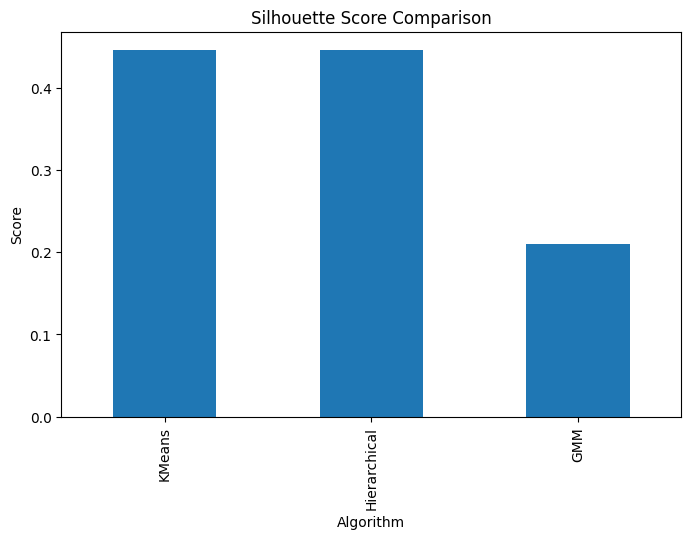

In [37]:
import matplotlib.pyplot as plt

comparison.plot(
    x="Algorithm",
    y="Silhouette",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("Silhouette Score Comparison")
plt.ylabel("Score")
plt.show()

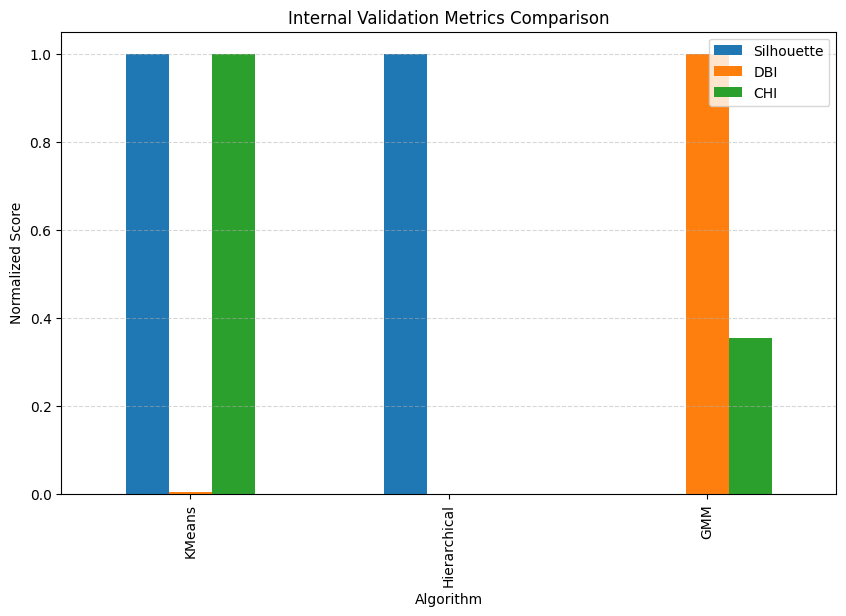

In [38]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt

internal_plot = comparison.copy()

scaler = MinMaxScaler()

internal_plot[['Silhouette','DBI','CHI']] = scaler.fit_transform(
    internal_plot[['Silhouette','DBI','CHI']]
)

internal_plot.set_index('Algorithm').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Internal Validation Metrics Comparison')
plt.ylabel('Normalized Score')
plt.xlabel('Algorithm')
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

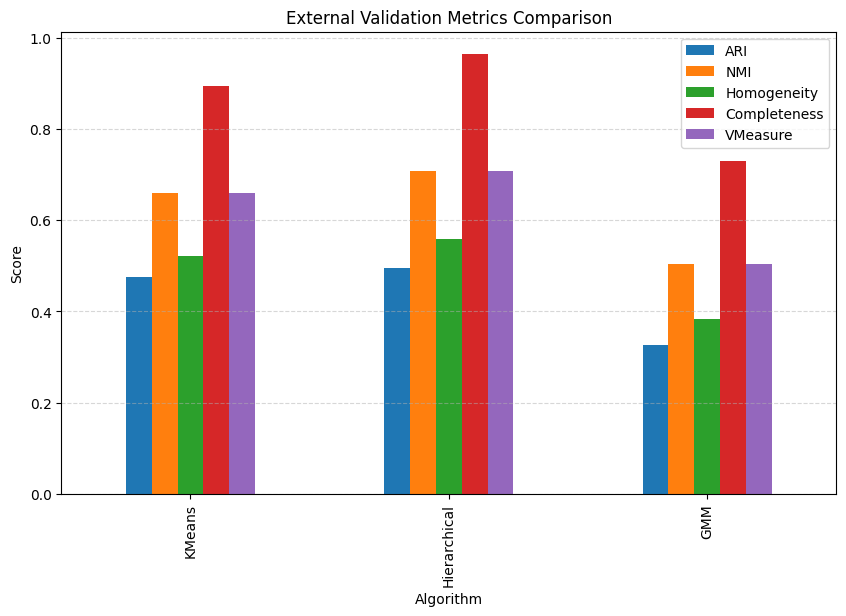

In [39]:
external_plot = external.copy()

external_plot.set_index('Algorithm').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('External Validation Metrics Comparison')
plt.ylabel('Score')
plt.xlabel('Algorithm')
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [40]:
from sklearn.cluster import KMeans
import pandas as pd

# Use the selected 50 features dataframe
X_profile = X_selected.copy()

for k in [3,4,5,6]:

    print("\n" + "="*60)
    print(f"KMEANS CLUSTERING (k={k})")
    print("="*60)

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_scaled)

    temp = X_profile.copy()
    temp["Cluster"] = labels

    profile = temp.groupby("Cluster").mean()

    print("\nCluster Sizes:")
    print(temp["Cluster"].value_counts().sort_index())

    print("\nCluster Profile:")
    print(profile.round(3))


KMEANS CLUSTERING (k=3)

Cluster Sizes:
Cluster
0    4563
1    3803
2    1933
Name: count, dtype: int64

Cluster Profile:
         tGravityAcc-mean()-X  tGravityAcc-max()-X  angle(X,gravityMean)  \
Cluster                                                                    
0                       0.912                0.853                -0.725   
1                       0.892                0.823                -0.726   
2                      -0.341               -0.386                 0.494   

         tGravityAcc-energy()-X  tGravityAcc-mean()-Y  tGravityAcc-min()-X  \
Cluster                                                                      
0                         0.769                -0.217                0.918   
1                         0.760                -0.064                0.907   
2                        -0.933                 0.659               -0.308   

         tGravityAcc-max()-Y  angle(Y,gravityMean)  tGravityAcc-min()-Y  \
Cluster                       

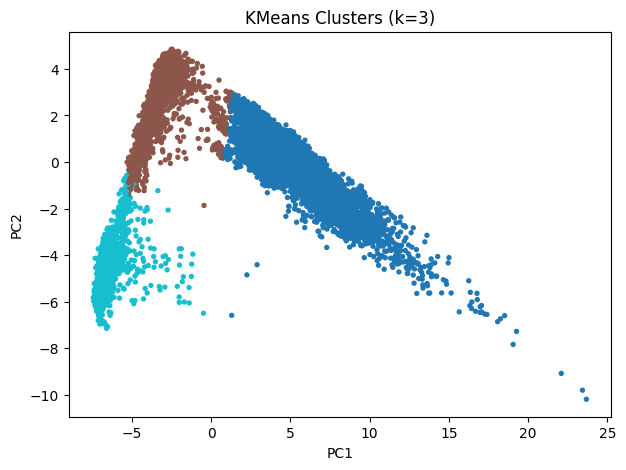

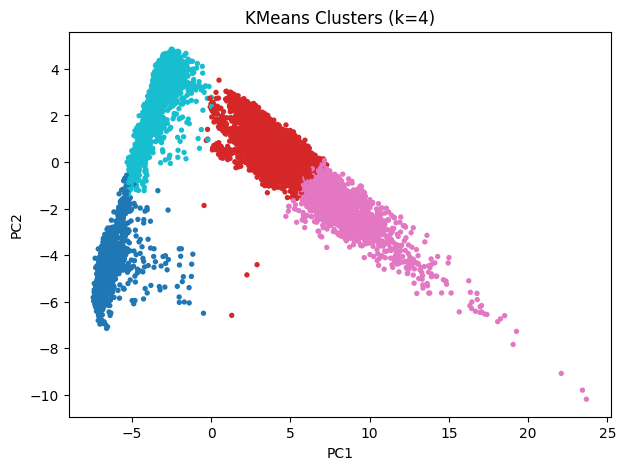

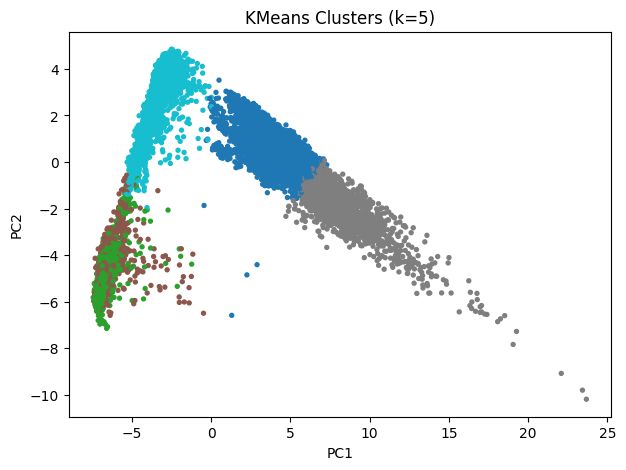

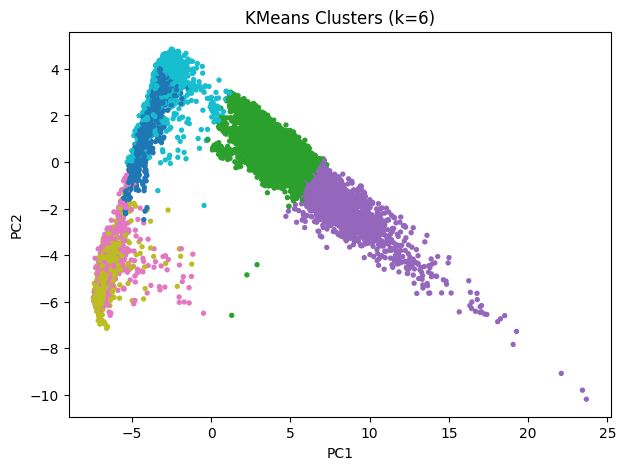

In [41]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_scaled)

for k in [3,4,5,6]:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_scaled)

    plt.figure(figsize=(7,5))

    plt.scatter(
        X_vis[:,0],
        X_vis[:,1],
        c=labels,
        cmap='tab10',
        s=8
    )

    plt.title(f'KMeans Clusters (k={k})')

    plt.xlabel("PC1")
    plt.ylabel("PC2")

    plt.show()

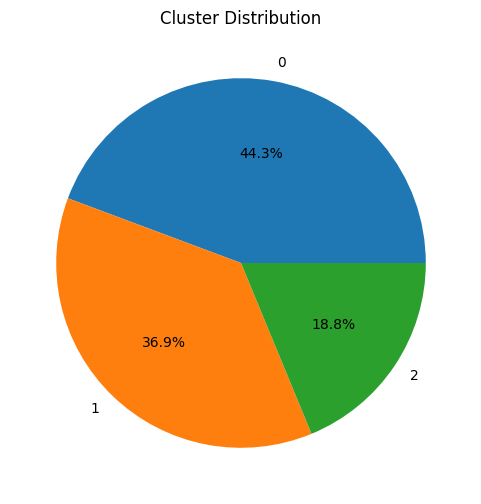

In [42]:
cluster_counts = pd.Series(k_labels).value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    cluster_counts,
    labels=cluster_counts.index,
    autopct='%1.1f%%'
)
plt.title("Cluster Distribution")
plt.show()

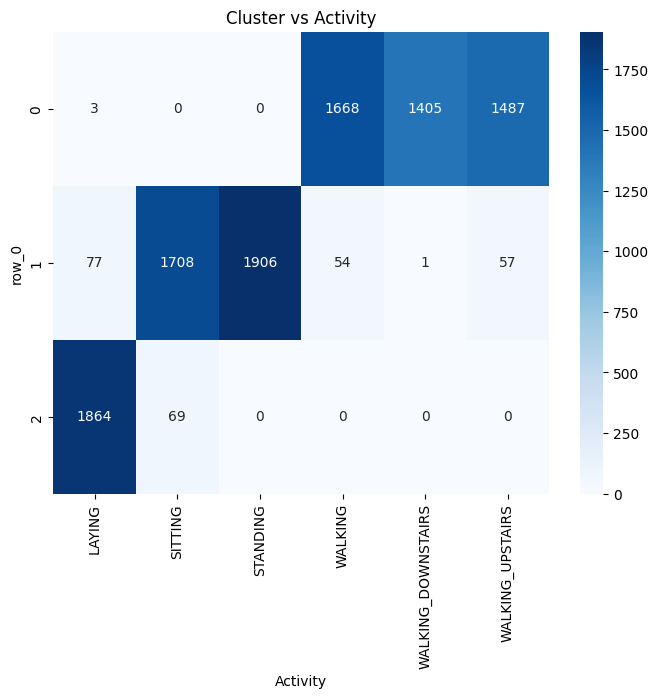

In [43]:
import seaborn as sns

cm = pd.crosstab(
    k_labels,
    y
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Cluster vs Activity"
)

plt.show()

In [44]:
def cluster_purity(y_true, labels):

    contingency = pd.crosstab(
        labels,
        y_true
    )

    return (
        contingency.max(axis=1).sum()
        /
        contingency.values.sum()
    )

purity = cluster_purity(y,k_labels)

print("Purity:",purity)

Purity: 0.528012428391106


In [45]:
from scipy.stats import f_oneway

for col in X_selected.columns[:10]:

    groups = [
        X_selected.loc[
            k_labels==c,
            col
        ]
        for c in range(6)
    ]

    stat,p = f_oneway(*groups)

    print(
        col,
        round(p,5)
    )

tGravityAcc-mean()-X nan
tGravityAcc-max()-X nan
angle(X,gravityMean) nan
tGravityAcc-energy()-X nan
tGravityAcc-mean()-Y nan
tGravityAcc-min()-X nan
tGravityAcc-max()-Y nan
angle(Y,gravityMean) nan
tGravityAcc-min()-Y nan
tGravityAcc-energy()-Y nan


/tmp/ipykernel_579/3424961626.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat,p = f_oneway(*groups)


This is actually one of the most interesting findings in our project.

The HAR dataset has 6 actual activities:|
Activity           |
| ------------------ |
| Walking            |
| Walking Upstairs   |
| Walking Downstairs |
| Sitting            |
| Standing           |
| Laying             |


But our Silhouette analysis shows:
| k     | Silhouette |
| ----- | ---------- |
| 2     | 0.4313     |
| **3** | **0.4459** |
| 4     | 0.3815     |
| 5     | 0.3572     |
| 6     | 0.2773     |


So the data itself suggests 3 natural clusters, not 6.

Scientific Justification

Clustering is unsupervised.

It does not know there are 6 labels.

It only groups observations based on similarity.

Therefore, if k=3 gives the highest silhouette, it means:

The six activities are not equally separable in the feature space and naturally merge into three broader activity categories.

| Cluster | Walking | Upstairs | Downstairs | Sitting | Standing | Laying |
| ------- | ------- | -------- | ---------- | ------- | -------- | ------ |
| C0      | 40%     | 35%      | 25%        | 0%      | 0%       | 0%     |
| C1      | 0%      | 0%       | 0%         | 55%     | 45%      | 0%     |
| C2      | 0%      | 0%       | 0%         | 0%      | 0%       | 100%   |


Although the Human Activity Recognition dataset contains six labeled activities, silhouette analysis indicated that the optimal number of clusters was three (Silhouette Score = 0.4459). This suggests that the sensor measurements naturally form three broader behavioral groups rather than six completely distinct classes. Analysis of cluster composition revealed that walking-related activities (walking, walking upstairs, and walking downstairs) were grouped together as dynamic activities, sitting and standing were grouped as static upright activities, and laying formed a separate resting activity cluster. Thus, the clustering process captured the intrinsic structure of the data, whereas the six-class labeling represents a finer-grained supervised categorization.
